<a href="https://colab.research.google.com/github/bcalm-2/llm_bootcamp/blob/main/llm_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Cat images: 12501
Dog images: 12501


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Split complete.
Classes: ['cats', 'dogs']
Train size: 19998 Test size: 5000
CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)
Epoch 1/8 - loss: 0.5979
Epoch 2/8 - loss: 0.4936
Epoch 3/8 - loss: 0.4327
Epoch 4/8 - loss: 0.3793
Epo

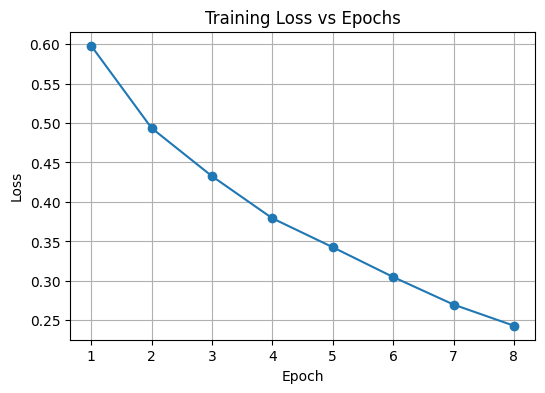

Accuracy : 0.8598
Precision: 0.8175079421108365
Recall   : 0.9264
F1 Score : 0.8685542846427902
ROC-AUC  : 0.9416904799999999

Confusion Matrix:
 [[1983  517]
 [ 184 2316]]

               precision    recall  f1-score   support

           0       0.92      0.79      0.85      2500
           1       0.82      0.93      0.87      2500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000

features.0.weight torch.Size([32, 3, 3, 3])
features.0.bias torch.Size([32])
features.3.weight torch.Size([64, 32, 3, 3])
features.3.bias torch.Size([64])
features.6.weight torch.Size([128, 64, 3, 3])
features.6.bias torch.Size([128])
classifier.1.weight torch.Size([128, 41472])
classifier.1.bias torch.Size([128])
classifier.4.weight torch.Size([1, 128])
classifier.4.bias torch.Size([1])
Model saved as catdog_cnn_state_dict.pth


In [1]:
# ============================================================
# STEP 0: Imports
# ============================================================
import os, shutil, random, zipfile
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ============================================================
# STEP 1: Download dataset directly into Colab (no PC involved)
# ============================================================
!wget --no-check-certificate "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" -O cats_and_dogs.zip -q

with zipfile.ZipFile('cats_and_dogs.zip', 'r') as z:
    z.extractall('raw_data')

print("Cat images:", len(os.listdir('raw_data/PetImages/Cat')))
print("Dog images:", len(os.listdir('raw_data/PetImages/Dog')))

# ============================================================
# STEP 2: Filter out corrupt images, then split into train/test (80/20)
# ============================================================
from PIL import Image

def is_valid_image(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception:
        return False

random.seed(42)
base = 'raw_data/PetImages'
for cls in ['Cat', 'Dog']:
    files_list = [f for f in os.listdir(f'{base}/{cls}') if f.endswith('.jpg')]
    files_list = [f for f in files_list if is_valid_image(f'{base}/{cls}/{f}')]
    random.shuffle(files_list)
    split_idx = int(0.8 * len(files_list))
    train_files, test_files = files_list[:split_idx], files_list[split_idx:]

    os.makedirs(f'data/train/{cls.lower()}s', exist_ok=True)
    os.makedirs(f'data/test/{cls.lower()}s', exist_ok=True)
    for f in train_files:
        shutil.copy(f'{base}/{cls}/{f}', f'data/train/{cls.lower()}s/{f}')
    for f in test_files:
        shutil.copy(f'{base}/{cls}/{f}', f'data/test/{cls.lower()}s/{f}')

print("Split complete.")

# ============================================================
# STEP 3: Transforms + DataLoaders
# ============================================================
IMG_SIZE = 150

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder('data/train', transform=train_transform)
test_dataset  = datasets.ImageFolder('data/test',  transform=test_transform)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset), "Test size:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# ============================================================
# STEP 4: CNN model
# ============================================================
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CatDogCNN().to(device)
print(model)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# STEP 5: Training loop
# ============================================================
epochs = 8
train_losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")

# ============================================================
# STEP 6: Loss vs Epochs graph
# ============================================================
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ============================================================
# STEP 7: Evaluation
# ============================================================
model.eval()
all_preds, all_probs, all_true = [], [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probs = torch.sigmoid(model(xb)).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

print("Accuracy :", accuracy_score(all_true, all_preds))
print("Precision:", precision_score(all_true, all_preds))
print("Recall   :", recall_score(all_true, all_preds))
print("F1 Score :", f1_score(all_true, all_preds))
print("ROC-AUC  :", roc_auc_score(all_true, all_probs))
print("\nConfusion Matrix:\n", confusion_matrix(all_true, all_preds))
print("\n", classification_report(all_true, all_preds))

# ============================================================
# STEP 8: View trained weights
# ============================================================
for name, param in model.named_parameters():
    print(name, param.shape)

# ============================================================
# STEP 9: Save model
# ============================================================
torch.save(model.state_dict(), 'catdog_cnn_state_dict.pth')
print("Model saved as catdog_cnn_state_dict.pth")